In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
import pickle

In [33]:
class Dataset_converter(Dataset):
    def __init__(self, data, token_size, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), token_size), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, token_size*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), token_size))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*token_size:(kk+1)*token_size] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [4]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=2, num_layers_sleep=2, output_size=7):
        super(brain, self).__init__()

        self.sleep_output_size = sleep_output_size
        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        self.wake_fc = nn.Linear(hidden_wake_size, output_size)

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False, short_term_memory=1, working_memory=1):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,short_term_memory,self.sleep_output_size))
            
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out[:,-1,:])

        if sleep:
            return out, hw, hs
        else:
            return out, hw


In [5]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [18]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask, token_size):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, token_size))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [19]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [20]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, token_size=7):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, token_size)
        
    def forward(self, x, hw=None, short_term_memory=None):
        if hw is None:
            out, hw = self.rnn(x)
        else:   
            out, hw = self.rnn(x, hw)
            
        out = self.fc1(out[:,-1,:])
        return out, hw


In [21]:
def wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=4e-4):
    data_set = Dataset_converter(train_data, token_size, working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)
    data_set = Dataset_converter(test_data, token_size, working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()

    total = 0
    correct_train = np.zeros(1000,dtype=float)
    correct_test = np.zeros(1000,dtype=float)
    train_acc = []
    test_acc = []
    for (X_train, y_train), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = model(X_train, short_term_memory=short_term_memory)
        else:
            predicted_y, hidden = model(X_train, hw=memory, short_term_memory=short_term_memory)

        
        loss = criterion(predicted_y, y_train)
        loss.backward(retain_graph=True)
        optimizer.step()

        with torch.no_grad():
            memory = hidden.clone()
            true_y = y_train.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)

            if total == 0:
                predicted_y_test, hidden_ = model(X_test, short_term_memory=short_term_memory)
            else:
                predicted_y_test, hidden_ = model(X_test, hw=hidden_, short_term_memory=short_term_memory)

            true_y_test = y_test.argmax(axis=1)
            estimated_y_test = predicted_y_test.argmax(axis=1)

            total += 1
            if true_y == estimated_y:
                correct_train[total%1000] = 1
            else:
                correct_train[total%1000] = 0


            if true_y_test == estimated_y_test:
                correct_test[total%1000] = 1
            else:
                correct_test[total%1000] = 0


            train_acc.append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            test_acc.append(
                np.sum(correct_test)/total if total<1000 else np.sum(correct_test)/1000
            )

            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}, test accuracy: {test_acc[-1]:.4f}')

    return model, train_acc, test_acc

In [43]:
def sleep_period(model, input_size, compressor_samples, sleep_samples, n_community, n_members, working_memory=1, short_term_memory=1, hidden_compressor_size=10, lr=4e-4, freeze_rnn1=False):

    token_size = n_community*n_members+1
    data_compressor = get_sequence(compressor_samples, n_community, n_members, train=True)
    data_set_compressor = Dataset_converter(data_compressor, token_size, working_memory, short_term_memory)
    compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

    ii = 0
    dis = [0]

    with torch.no_grad():
        for X, _ in compressor_loader:
            if ii==0:
                _, hw = model(X)
                id_current = hw
            else:
                _, hw = model(X, hw=hw)
                id_current = hw
                if ii>=1:
                    dis.append(compute_geodesic(prev_id, id_current)) 
                
            prev_id = id_current
            ii += 1

    dis_array = np.array(dis)
    peaks = [-100] 
    threshold = 0.2
    prev_dis = 1

    for ii, dis in enumerate(dis_array):
        if prev_dis - dis >= threshold and peaks[-1]!=ii-2:
            peaks.append(ii-1)
        
        prev_dis = dis 

    peaks.pop(0)
    mask = np.zeros(dis_array.shape, dtype=int)
    mask[peaks] = 1

    ##############################################################
    data_set = Dataset_converter_compressor(data_compressor, mask, token_size)
    compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    compressor_model = compressor(input_size, hidden_compressor_size)
    optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-4, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()

    total = 0
    for X, y in compressor_loader:
        optimizer.zero_grad()

        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mem = hidden.clone()

    ###############################################
    data_sleep = get_sequence(sleep_samples, n_community, n_members)
    data_set_sleep = Dataset_converter(data_sleep, token_size, working_memory, short_term_memory)
    sleep_loader_train = DataLoader(data_set_sleep, batch_size=1, shuffle=False)

    data_sleep = get_sequence(sleep_samples, n_community, n_members, train=False)
    data_set_sleep = Dataset_converter(data_sleep, token_size, working_memory, short_term_memory)
    sleep_loader_test = DataLoader(data_set_sleep, batch_size=1, shuffle=False)

    if freeze_rnn1:
        model.rnn.requires_grad = False
        model.wake_fc.requires_grad = False
    else:
        model.rnn.requires_grad = True
        model.wake_fc.requires_grad = True

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()

    total = 0
    hidden_s = None
    train_acc = []
    test_acc = []
    correct_train = np.zeros(1000,dtype=float)
    correct_test = np.zeros(1000,dtype=float)
    for (X, y), (X_test, y_test) in zip(sleep_loader_train, sleep_loader_test):

        with torch.no_grad():
            if total == 0:
                community = X.clone()
                prev_community = X.clone()
                predicted_y, hidden = compressor_model(X[0])
            else:
                predicted_y, hidden = compressor_model(X[0], hc=hidden)

            selection = predicted_y.argmax(axis=1)


            if selection:        
                community = prev_community.clone()
                prev_community = X.clone()
        ####################################################################
        optimizer.zero_grad()
        if total == 0:
            predicted_y, hidden_w, hidden_s = model(X, community, sleep=True)
        else:
            predicted_y, hidden_w, hidden_s = model(X, community, hw=mem, hs=mem_, sleep=True)

        #print(predicted_y.shape, y.shape)   
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mem=hidden_w.clone()
            mem_=hidden_s.clone()
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)

            if total == 0:
                predicted_y_test, hidden_ = model(X_test, short_term_memory=short_term_memory)
            else:
                predicted_y_test, hidden_ = model(X_test, hw=hidden_, short_term_memory=short_term_memory)

            true_y_test = y_test.argmax(axis=1)
            estimated_y_test = predicted_y_test.argmax(axis=1)

            total += 1
            if true_y == estimated_y:
                correct_train[total%1000] = 1
            else:
                correct_train[total%1000] = 0


            if true_y_test == estimated_y_test:
                correct_test[total%1000] = 1
            else:
                correct_test[total%1000] = 0


            train_acc.append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            test_acc.append(
                np.sum(correct_test)/total if total<1000 else np.sum(correct_test)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}, test accuracy: {test_acc[-1]:.4f}')

    return model, train_acc, test_acc

In [50]:
### initial training ###
total_samples = 100000
n_community = 2
n_members = 3
token_size = n_community*n_members+1
working_memory = 1
short_term_memory = 1
hidden_wake_size = 100
hidden_compressor_size = 10
hidden_sleep_size = 100
sleep_output_size = 10
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = token_size
input_size = token_size*working_memory
lr = 4e-4
test_acc_before_sleep = []

sleep_cycles = 5
compressor_samples = 20000
sleep_samples = 100000

train_data = get_sequence(total_samples, n_community, n_members)
test_data = get_sequence(total_samples, n_community, n_members, train=False)

model = brain(input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers_wake, num_layers_sleep, output_size=token_size)
model, train_acc_before_sleep, test_acc_before_sleep = wake_period(model, train_data, test_data, token_size, working_memory, short_term_memory, lr=lr)

train_acc_during_sleep, test_acc_during_sleep = [], []

for _ in range(sleep_cycles):
    model, train_acc, test_acc = sleep_period(model, input_size, compressor_samples, sleep_samples, n_community, n_members, working_memory=1, short_term_memory=1, hidden_compressor_size=10, lr=1e-5, freeze_rnn1=True)
    train_acc_during_sleep.append(train_acc)
    test_acc_during_sleep.append(test_acc)

model, train_acc, test_acc = sleep_period(model, input_size, compressor_samples, sleep_samples, n_community, n_members, working_memory=1, short_term_memory=1, hidden_compressor_size=10, lr=1e-5, freeze_rnn1=False)
train_acc_during_sleep.append(train_acc)
test_acc_during_sleep.append(test_acc)

Iter : 1001, loss: 1.9752, train accuracy: 0.2460, test accuracy: 0.2410
Iter : 2001, loss: 1.6976, train accuracy: 0.2710, test accuracy: 0.2500
Iter : 3001, loss: 1.3466, train accuracy: 0.5470, test accuracy: 0.2420
Iter : 4001, loss: 1.8868, train accuracy: 0.6560, test accuracy: 0.2620
Iter : 5001, loss: 1.5090, train accuracy: 0.6650, test accuracy: 0.2680
Iter : 6001, loss: 1.1205, train accuracy: 0.6940, test accuracy: 0.2140
Iter : 7001, loss: 1.1771, train accuracy: 0.6730, test accuracy: 0.2350
Iter : 8001, loss: 1.4022, train accuracy: 0.6650, test accuracy: 0.2530
Iter : 9001, loss: 2.2812, train accuracy: 0.6730, test accuracy: 0.2620
Iter : 10001, loss: 0.9752, train accuracy: 0.6890, test accuracy: 0.2500
Iter : 11001, loss: 1.1142, train accuracy: 0.6820, test accuracy: 0.2340
Iter : 12001, loss: 0.9319, train accuracy: 0.6770, test accuracy: 0.2300
Iter : 13001, loss: 0.9856, train accuracy: 0.6770, test accuracy: 0.2290
Iter : 14001, loss: 1.5500, train accuracy: 0.6

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the RNN model
class ClusteredDirectionalRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ClusteredDirectionalRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

# One-hot encoded tokens
tokens = {
    "A": torch.tensor([1, 0, 0, 0, 0, 0, 0], dtype=torch.float32),
    "B": torch.tensor([0, 1, 0, 0, 0, 0, 0], dtype=torch.float32),
    "C": torch.tensor([0, 0, 1, 0, 0, 0, 0], dtype=torch.float32),
    "D": torch.tensor([0, 0, 0, 1, 0, 0, 0], dtype=torch.float32),
    "E": torch.tensor([0, 0, 0, 0, 1, 0, 0], dtype=torch.float32),
    "F": torch.tensor([0, 0, 0, 0, 0, 1, 0], dtype=torch.float32),
    "G": torch.tensor([0, 0, 0, 0, 0, 0, 1], dtype=torch.float32),
}

# Define clusters
clusters = {
    "Cluster1": ["A", "B", "C"],
    "Cluster2": ["D", "E", "F"]
}

# Generate training data
train_data = []

# Direction 0: Always output G
for token in tokens.keys():
    train_data.append((torch.cat((tokens[token], torch.tensor([0.0]))), tokens["G"]))

# Direction 1: Clockwise rotation within clusters
for cluster in clusters.values():
    for i, token in enumerate(cluster):
        next_token = cluster[(i + 1) % len(cluster)]
        train_data.append((torch.cat((tokens[token], torch.tensor([1.0]))), tokens[next_token]))

# Direction 2: Counterclockwise rotation within clusters
for cluster in clusters.values():
    for i, token in enumerate(cluster):
        next_token = cluster[(i - 1) % len(cluster)]
        train_data.append((torch.cat((tokens[token], torch.tensor([2.0]))), tokens[next_token]))

# Hyperparameters
input_size = 8  # 7 for one-hot + 1 for direction input
hidden_size = 10  # Arbitrary hidden size
output_size = 7  # One-hot encoded output
num_epochs = 1000
learning_rate = 0.01

# Model, loss, and optimizer
model = ClusteredDirectionalRNN(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training
for epoch in range(num_epochs):
    total_loss = 0
    for input_token, target_token in train_data:
        # Reshape input for batch and sequence dimensions
        input_token = input_token.unsqueeze(0).unsqueeze(0)  # (batch, seq_len, input_size)
        target_token = target_token.unsqueeze(0)  # (batch, output_size)
        
        hidden = torch.zeros(1, 1, hidden_size)  # Initialize hidden state
        
        # Forward pass
        output, hidden = model(input_token, hidden)
        loss = criterion(output.squeeze(0), torch.argmax(target_token).unsqueeze(0))
        total_loss += loss.item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {total_loss:.4f}')

# Testing
def predict(token, direction):
    # Concatenate direction input (0, 1, or 2) to the one-hot token
    input_token = torch.cat((tokens[token], torch.tensor([float(direction)]))).unsqueeze(0).unsqueeze(0)
    hidden = torch.zeros(1, 1, hidden_size)
    output, _ = model(input_token, hidden)
    predicted_idx = torch.argmax(output).item()
    for key, value in tokens.items():
        if value[predicted_idx] == 1:
            return key

print("Testing the RNN with Clusters:")
for direction in [0, 1, 2]:
    for token in tokens.keys():
        print(f"Input: {token}, Direction: {direction} -> Output: {predict(token, direction)}")


Epoch [100/1000], Loss: 0.9014
Epoch [200/1000], Loss: 0.1075
Epoch [300/1000], Loss: 0.0284
Epoch [400/1000], Loss: 0.0093
Epoch [500/1000], Loss: 0.0033
Epoch [600/1000], Loss: 0.0012
Epoch [700/1000], Loss: 0.0004
Epoch [800/1000], Loss: 0.0002
Epoch [900/1000], Loss: 0.0001
Epoch [1000/1000], Loss: 0.0000
Testing the RNN with Clusters:
Input: A, Direction: 0 -> Output: G
Input: B, Direction: 0 -> Output: G
Input: C, Direction: 0 -> Output: G
Input: D, Direction: 0 -> Output: G
Input: E, Direction: 0 -> Output: G
Input: F, Direction: 0 -> Output: G
Input: G, Direction: 0 -> Output: G
Input: A, Direction: 1 -> Output: B
Input: B, Direction: 1 -> Output: C
Input: C, Direction: 1 -> Output: A
Input: D, Direction: 1 -> Output: E
Input: E, Direction: 1 -> Output: F
Input: F, Direction: 1 -> Output: D
Input: G, Direction: 1 -> Output: G
Input: A, Direction: 2 -> Output: C
Input: B, Direction: 2 -> Output: A
Input: C, Direction: 2 -> Output: B
Input: D, Direction: 2 -> Output: F
Input: E, 

In [ ]:
import pickle 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
from tqdm import tqdm 

bptts = [1, 3, 5, 7]
nodes = [5,10,15,20,25,30,35]
reps = 10
downsample = 200

fig, ax = plt.subplots(2, len(bptts), figsize=(8*len(bptts),8*2), sharex=True, sharey=True)

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("bright", n_colors=len(nodes))
font = 40
algo = ['ablation_', '']

for kk, name in enumerate(algo):
    for ii, bptt in enumerate(bptts):
        for jj, node in enumerate(nodes):
            filename = '/Users/jd/sleep_experiment/pickle_files/chunking_'+name+str(bptt)+'_'+str(node)

            # print('Loading ', filename)
            with open(filename, 'rb') as f:
                res = np.array(pickle.load(f)[:reps])


            # res = np.concatenate((res[:,:38000], res[:,61000:]), axis=1)
            total_samples = len(res[0])
            samples = np.arange(1,total_samples+1)

            idx = list(range(1,total_samples,downsample))

            if ii==0 and kk==0:
                ax[kk][ii].plot(samples[idx], np.median(1-res[:,idx],axis=0),linewidth=4, c=clr[jj], label= str(node)+' neurons')
            else:
                ax[kk][ii].plot(samples[idx], np.median(1-res[:,idx],axis=0),linewidth=4, c=clr[jj])

            ax[kk][ii].fill_between(samples[idx], np.quantile(1-res[:,idx], 0.25, axis=0), np.quantile(1-res[:,idx], 0.75, axis=0), facecolor=clr[jj], alpha=.3)

        if ii==0 and kk==0:
            ax[kk][ii].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed', linewidth=4, color='k', label='Optimal Performance')  
        else:
            ax[kk][ii].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed',linewidth=4, color='k')    

        ax[kk][ii].vlines(40000, 0.2, .9, color='k') 


        ax[kk][ii].tick_params(labelsize=font)

        # ax.set_title('# layer '+str(2),fontsize=font)


        right_side = ax[kk][ii].spines["right"]
        right_side.set_visible(False)
        top_side = ax[kk][ii].spines["top"]
        top_side.set_visible(False)

                

                
        #     ax[1][ii].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')
        #     ax[1][ii].tick_params(labelsize=40)

        #     right_side = ax[1][ii].spines["right"]
        #     right_side.set_visible(False)
        #     top_side = ax[1][ii].spines["top"]
        #     top_side.set_visible(False)

        # ax[0][5].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance', color='k')      
        # ax[0][0].set_ylabel('Train Error', fontsize=font)
        # ax[1][0].set_ylabel('Test Error', fontsize=font)
        # #ax[1][3].set_xlabel('Samples Seen', fontsize=font+20)
        ax[kk][ii].set_yticks([0,.2,1])
        ax[kk][ii].set_xticks([0, 200000])
        if kk == 0:
            ax[kk][ii].set_title('BPTT window '+str(bptt), fontsize=font)
        # ax[ii].text(10000,.85,'Mode',fontsize=font)
        ax[kk][ii].text(10000,.45,'Pre-sleep Wake',fontsize=font-8, rotation=90)
        ax[kk][ii].text(50000,.45,'Post-sleep Wake',fontsize=font-8, rotation=90)
        # ax[ii].text(60000,.6,'Step 2',fontsize=font-5, rotation=90)

    if kk==0:
        ax[kk][0].set_ylabel('With wrong context tag\n Prediction Error', fontsize=font)
    else:
        ax[kk][0].set_ylabel('With context tag\n Prediction Error', fontsize=font)
    
fig.text(.45, -.02, 'Time Instants', fontsize=font)

    # fig.text(.2,.6,'Step 1',fontsize=font-5, rotation=90)
    # fig.text(.3,.6,'Step 2',fontsize=font-5, rotation=90)
fig.legend(bbox_to_anchor=(0.52, -0.03), bbox_transform=plt.gcf().transFigure,
                        ncol=4, loc='upper center', fontsize=font, frameon=False)

plt.savefig('plots/chunked_model.pdf', bbox_inches='tight')

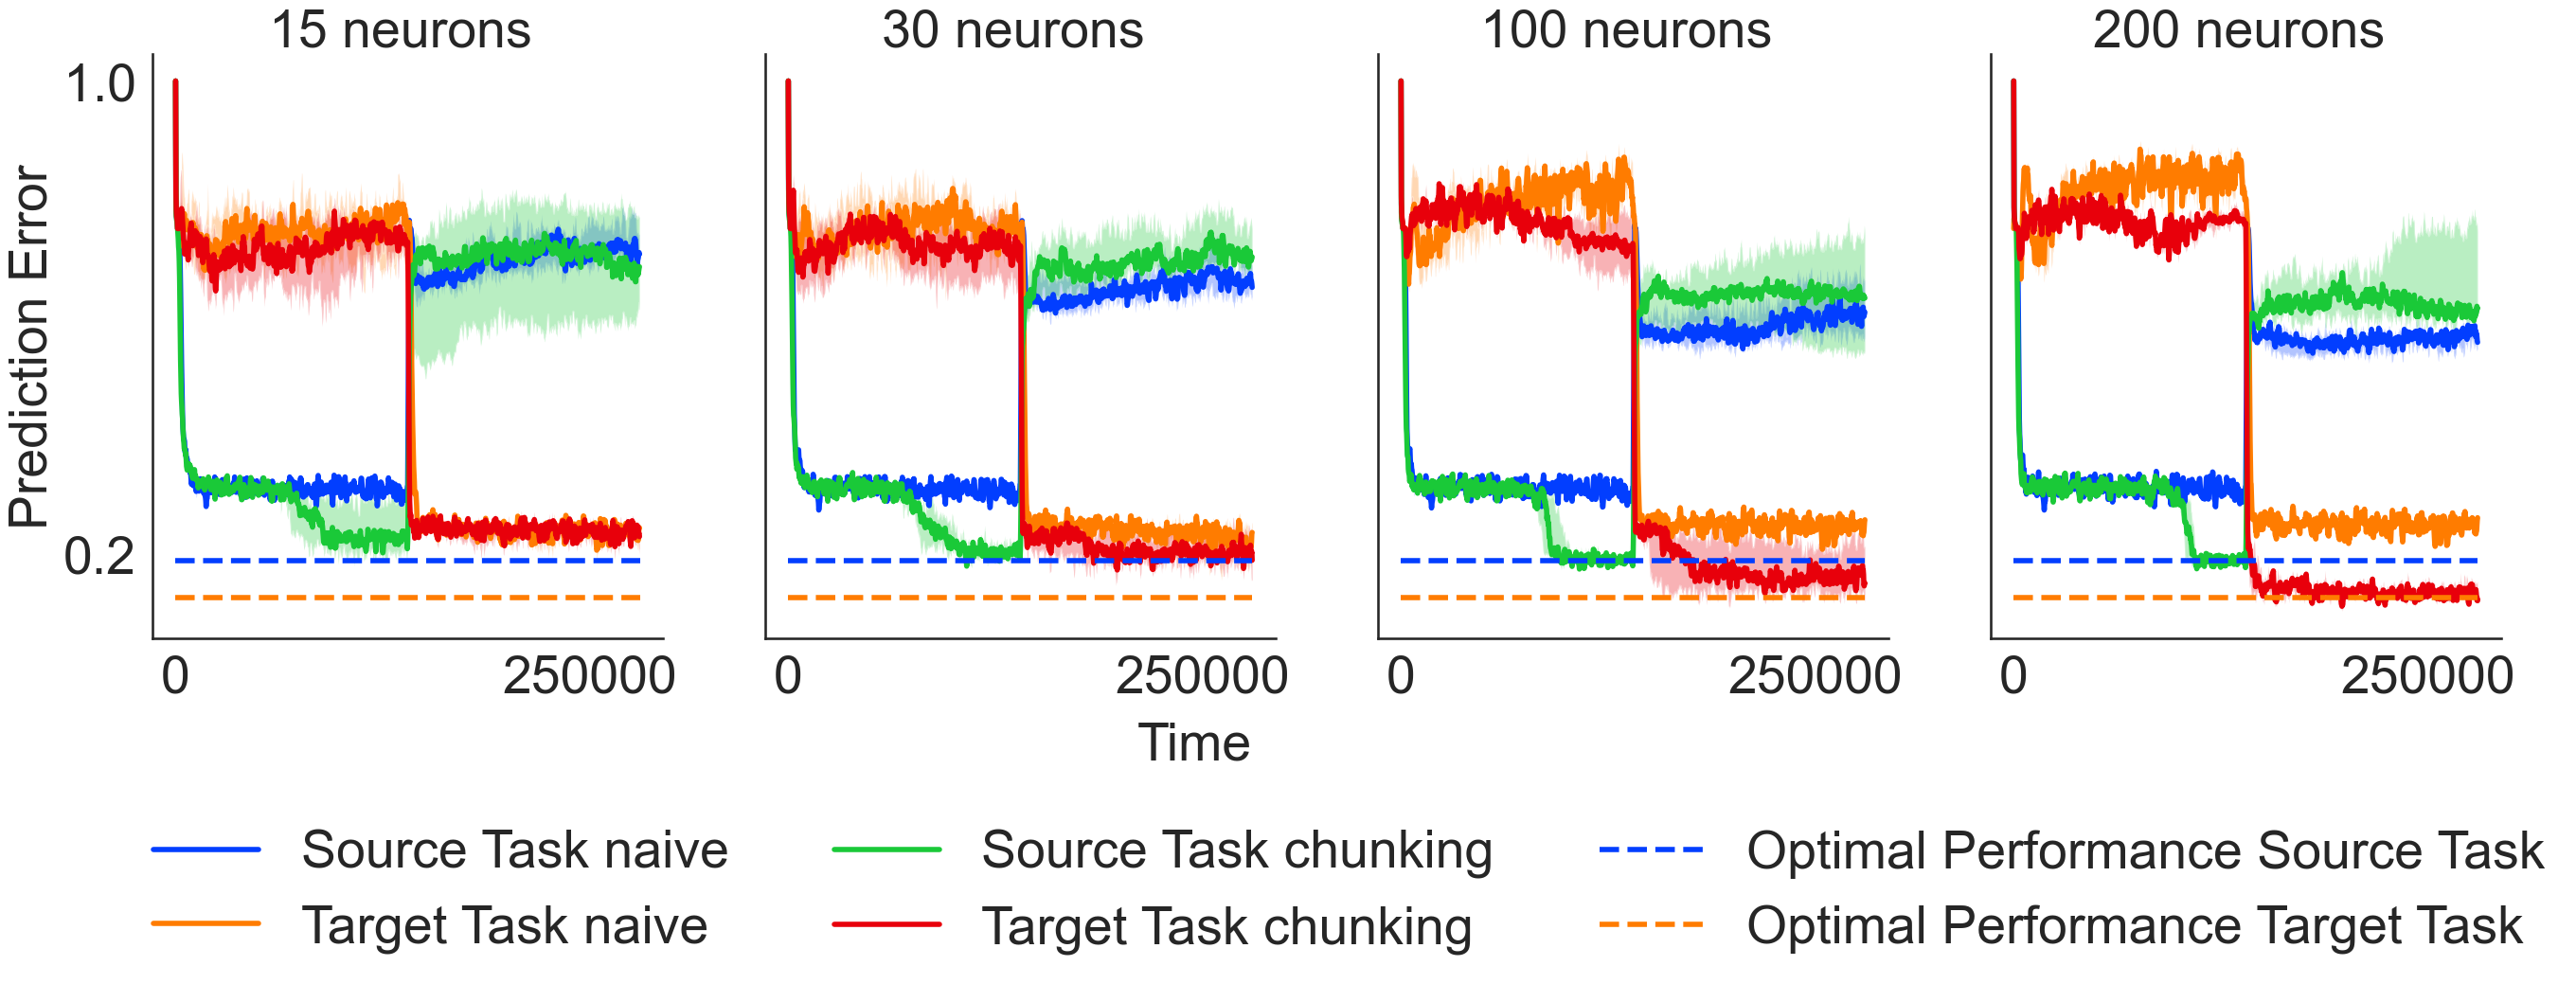

In [21]:
import pickle 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

nodes = [15, 30, 100, 200]
reps = 5
downsample = 200
algos = ['naive', 'chunking']
linestyles = ['-', '-']
fig, ax = plt.subplots(1, len(nodes), figsize=(8*len(nodes),8), sharex=True, sharey=True)

sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
clr = sns.color_palette("bright", n_colors=4)
font = 40

for ii, algo in enumerate(algos):
    for jj, node in enumerate(nodes):
        if ii == 1:
            filename = 'pickle_files/chunking_CL_'+str(1)+'_'+str(node)
        else:
            filename = 'pickle_files/chunking_naive_rnn_'+str(1)+'_'+str(node)

        with open(filename, 'rb') as f:
            task1, task2 = pickle.load(f)

        task1, task2 = np.array(task1), np.array(task2)
        # res = np.concatenate((res[:,:38000], res[:,61000:]), axis=1)
        total_samples = len(task1[0])
        idx = list(range(1,total_samples,downsample))
        samples = np.arange(1,total_samples+1)

        if jj==0:
            ax[jj].plot(samples[idx], np.median(1-task1[:,idx],axis=0),linewidth=4, c=clr[0+2*ii], label='Source Task '+algo, linestyle=linestyles[ii])
            ax[jj].fill_between(samples[idx], np.quantile(1-task1[:,idx], 0.25, axis=0), np.quantile(1-task1[:,idx], 0.75, axis=0), facecolor=clr[0+2*ii], alpha=.3)
            
            ax[jj].plot(samples[idx], np.median(1-task2[:,idx],axis=0),linewidth=4, c=clr[1+2*ii], label='Target Task '+algo, linestyle=linestyles[ii])
            ax[jj].fill_between(samples[idx], np.quantile(1-task2[:,idx], 0.25, axis=0), np.quantile(1-task2[:,idx], 0.75, axis=0), facecolor=clr[1+2*ii], alpha=.3)
        else:
            ax[jj].plot(samples[idx], np.median(1-task1[:,idx],axis=0),linewidth=4, c=clr[0+2*ii], linestyle=linestyles[ii])
            ax[jj].fill_between(samples[idx], np.quantile(1-task1[:,idx], 0.25, axis=0), np.quantile(1-task1[:,idx], 0.75, axis=0), facecolor=clr[0+2*ii], alpha=.3)

            ax[jj].plot(samples[idx], np.median(1-task2[:,idx],axis=0),linewidth=4, c=clr[1+2*ii], linestyle=linestyles[ii])
            ax[jj].fill_between(samples[idx], np.quantile(1-task2[:,idx], 0.25, axis=0), np.quantile(1-task2[:,idx], 0.75, axis=0), facecolor=clr[1+2*ii], alpha=.3)


        # ax[jj].hlines(1-(3.0+1/6.0)/4, 0, total_samples, linestyles='dashed', color='k', label='Optimal Performance')   

        # ax[jj].vlines(40000, 0, 1, color='k') 


        ax[jj].tick_params(labelsize=font)

        # ax.set_title('# layer '+str(2),fontsize=font)


        right_side = ax[jj].spines["right"]
        right_side.set_visible(False)
        top_side = ax[jj].spines["top"]
        top_side.set_visible(False)

         
        
        ax[jj].set_yticks([0,.2,1])
        ax[jj].set_xticks([0,250000])
        
        ax[jj].set_title(str(node)+' neurons ', fontsize=font)

for jj, node in enumerate(nodes):
    if jj == 0:
            ax[jj].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance Source Task', color=clr[0], linewidth=4)  
            ax[jj].hlines(1-(3.0+1/2)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance Target Task', color=clr[1], linewidth=4) 
    else:
        ax[jj].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', color=clr[0], linewidth=4)  
        ax[jj].hlines(1-(3.0+1/2)/4, 0, total_samples, linestyles='dashed', color=clr[1], linewidth=4)

ax[0].set_ylabel('Prediction Error', fontsize=font) 
fig.text(.45, -.05, 'Time', fontsize=font)      
#     ax[1][ii].hlines(1-(3.0+1/6)/4, 0, total_samples, linestyles='dashed', color='k')
#     ax[1][ii].tick_params(labelsize=40)

#     right_side = ax[1][ii].spines["right"]
#     right_side.set_visible(False)
#     top_side = ax[1][ii].spines["top"]
#     top_side.set_visible(False)

# ax[0][5].hlines(1-(3.0+1/4)/4, 0, total_samples, linestyles='dashed', label='Optimal Performance', color='k')      
# ax[0][0].set_ylabel('Train Error', fontsize=font)
# ax[1][0].set_ylabel('Test Error', fontsize=font)
# #ax[1][3].set_xlabel('Samples Seen', fontsize=font+20)


# fig.text(.2,.6,'Step 1',fontsize=font-5, rotation=90)
# fig.text(.3,.6,'Step 2',fontsize=font-5, rotation=90)
fig.legend(bbox_to_anchor=(0.52, -0.08), bbox_transform=plt.gcf().transFigure,
                        ncol=3, loc='upper center', fontsize=font, frameon=False)

plt.savefig('plots/chunked_model_CL.pdf', bbox_inches='tight')